# Model Comparison

Loads saved evaluation results from all three models and produces comparison tables and charts.

**Prerequisites:** run `t5_small.ipynb`, `t5_base.ipynb`, and `mbart.ipynb` first so that `results/` folders are populated.

## 0. Setup

In [8]:
# Clone repo if needed and install dependencies
!git clone https://github.com/PetraMicanovic/nlp-robot-command-parser.git 2>/dev/null || echo "Repo already present"
%cd nlp-robot-command-parser

/content/nlp-robot-command-parser/nlp-robot-command-parser


In [9]:
!pip install -q -r requirements.txt

In [10]:
import sys, os

IN_COLAB = 'google.colab' in sys.modules or os.path.exists('/content')

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Google Drive mounted.')
else:
    print('Local environment — skipping Drive mount.')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Google Drive mounted.


In [11]:
import json, os
import pandas as pd
import matplotlib.pyplot as plt

DRIVE_RESULTS = '/content/drive/MyDrive/nlp-robot-command-parser/results'
LOCAL_RESULTS = os.path.join(os.getcwd(), 'results')

if IN_COLAB and os.path.isdir(DRIVE_RESULTS):
    RESULTS_ROOT = DRIVE_RESULTS
else:
    RESULTS_ROOT = LOCAL_RESULTS

print(f'Using results root: {RESULTS_ROOT}')

models = {
    'model': ('t5-small', os.path.join(RESULTS_ROOT, 't5-small')),
    'model_t5_base': ('t5-base', os.path.join(RESULTS_ROOT, 't5-base')),
    'model_mbart': ('mbart', os.path.join(RESULTS_ROOT, 'mbart')),
}

splits = ['simple', 'length', 'addprim_jump', 'addprim_turn_left', 'template_around_right', 'template_jump_around_right', 'template_opposite_right', 'template_right','filler_num0', 'filler_num1', 'filler_num2', 'filler_num3','fewshot_num8_rep1',]

print("Results directories:")
for key, (name, path) in models.items():
    if os.path.isdir(path):
        print(f"{name}: {path}")
    else:
        print("NOT FOUND")



Using results root: /content/drive/MyDrive/nlp-robot-command-parser/results
Results directories:
t5-small: /content/drive/MyDrive/nlp-robot-command-parser/results/t5-small
t5-base: /content/drive/MyDrive/nlp-robot-command-parser/results/t5-base
mbart: /content/drive/MyDrive/nlp-robot-command-parser/results/mbart


## 1. Exact match across SCAN splits

In [ ]:
rows = []
for model_key, (model_name, results_dir) in models.items():
    for split in splits:
        fpath = os.path.join(results_dir, f'evaluation_{split}.json')
        if not os.path.exists(fpath):
            print(f"Missing: {fpath}")
            continue
        with open(fpath) as f:
            r = json.load(f)
        rows.append({
            'model': model_name,
            'split': split,
            'exact_match': r['exact_match'],
        })

if not rows:
    print('\nNo results loaded- check that evaluation files exist.')
else:
    df_splits = pd.DataFrame(rows)
    df_pivot = df_splits.pivot(index='split', columns='model', values='exact_match')
    print(df_pivot.to_string())

model                        mbart  t5-base  t5-small
split                                                
addprim_jump                0.5671    0.745     0.655
addprim_turn_left           0.6308    0.880     0.770
fewshot_num8_rep1           0.2702    0.360     0.155
filler_num0                 0.2702    0.360     0.155
filler_num1                 0.2702    0.360     0.155
filler_num2                 0.2702    0.360     0.155
filler_num3                 0.2702    0.360     0.155
length                      0.0000    0.000     0.000
simple                      0.5289    0.725     0.610
template_around_right       0.2764    0.380     0.150
template_jump_around_right  0.2702    0.360     0.155
template_opposite_right     0.6841    0.805     0.715
template_right              0.6908    0.870     0.770


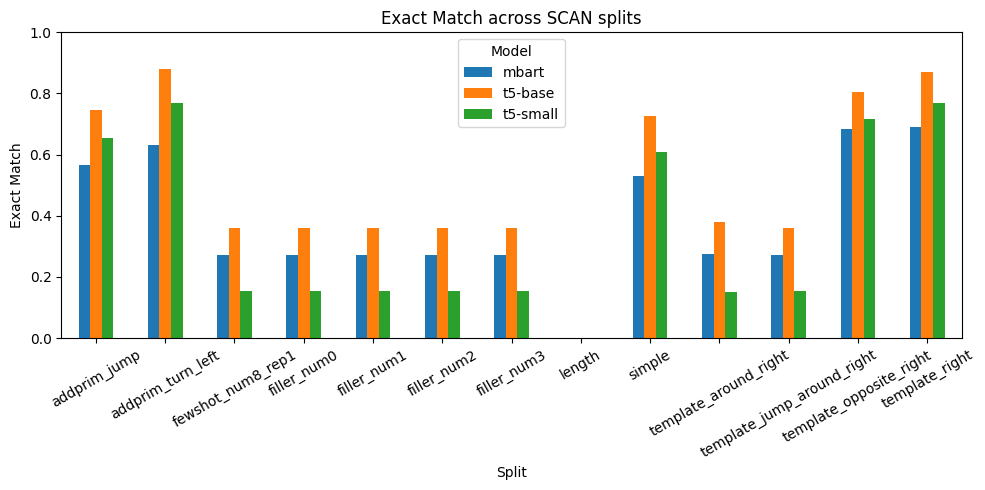

Chart saved to /content/drive/MyDrive/nlp-robot-command-parser/results/comparison_splits.png


In [ ]:
if 'df_pivot' in dir() and not df_pivot.empty:
    ax = df_pivot.plot(kind='bar', figsize=(10, 5), rot=30)
    ax.set_title('Exact Match across SCAN splits')
    ax.set_ylabel('Exact Match')
    ax.set_xlabel('Split')
    ax.legend(title='Model')
    ax.set_ylim(0, 1)
    plt.tight_layout()

    out_path = os.path.join(RESULTS_ROOT, 'comparison_splits.png')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Chart saved to {out_path}')

## 2. HuRIC evaluation

In [ ]:
huric_rows = []
for model_key, (model_name, results_dir) in models.items():
    fpath = os.path.join(results_dir, 'evaluation_huric.json')
    if not os.path.exists(fpath):
        print(f"Missing: {fpath}")
        continue
    with open(fpath) as f:
        r = json.load(f)
    huric_rows.append({
        'model': model_name,
        'exact_match': r['exact_match'],
        'n_evaluated': r['n_evaluated'],
    })

if not huric_rows:
    print('No HuRIC results found.')
else:
    df_huric = pd.DataFrame(huric_rows).set_index('model')
    print(df_huric.to_string())

          exact_match  n_evaluated
model                             
t5-small       0.1111           18
t5-base        0.1667           18
mbart          0.1111           18


## 3. End-to-end pipeline accuracy (Audio → Text → Actions)

In [ ]:
pipeline_rows = []
for model_key, (model_name, results_dir) in models.items():
    fpath = os.path.join(results_dir, 'evaluation_pipeline.json')
    if not os.path.exists(fpath):
        print(f"Missing: {fpath}")
        continue
    with open(fpath) as f:
        r = json.load(f)
    pipeline_rows.append({
        'model': model_name,
        'with_normalization': r['with_normalization']['exact_match'],
        'without_normalization': r['without_normalization']['exact_match'],
    })

if not pipeline_rows:
    print ('No pipeline results found.')
else:
    df_pipeline = pd.DataFrame(pipeline_rows).set_index('model')
    print(df_pipeline.to_string())

          with_normalization  without_normalization
model                                              
t5-small                0.59                   0.07
t5-base                 0.69                   0.06
mbart                   0.43                   0.18


## 4. Error analysis by command length

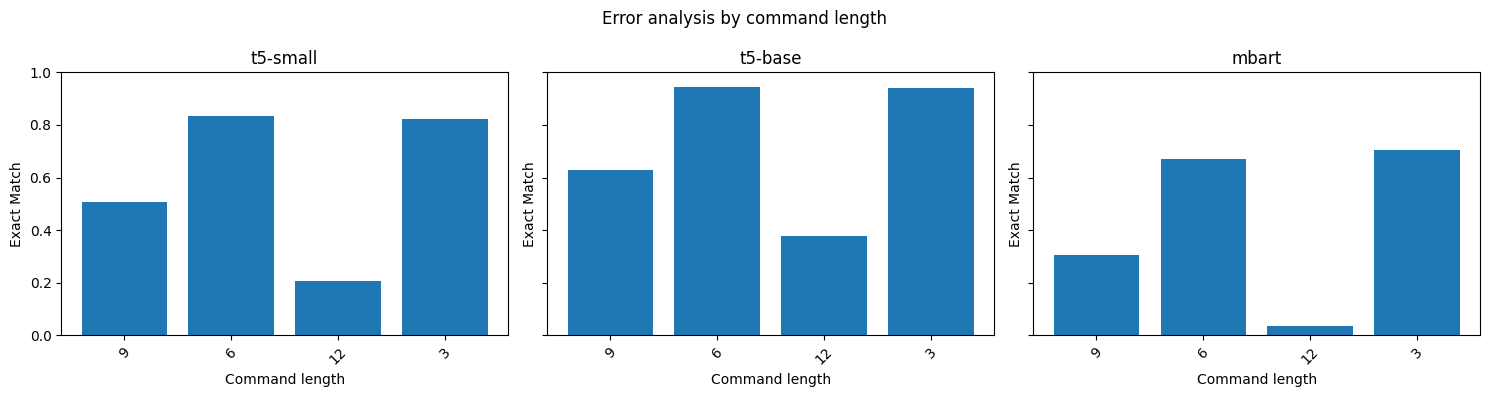

Chart saved to results/comparison_length.png


In [ ]:
fig, axes = plt.subplots(1, len(models), figsize=(15, 4), sharey=True)

for ax, (model_key, (model_name, results_dir)) in zip(axes, models.items()):
    fpath = os.path.join(results_dir, 'length_analysis', 'length_analysis.json')
    if not os.path.exists(fpath):
        ax.set_title(f'{model_name}\n(no data)')
        continue
    with open(fpath) as f:
        buckets = json.load(f)
    lengths = list(buckets.keys())
    accuracies = []
    for l in lengths:
        accuracies.append(buckets[l].get('exact_match', 0))
    ax.bar(lengths, accuracies)
    ax.set_title(model_name)
    ax.set_xlabel('Command length')
    ax.set_ylabel('Exact Match')
    ax.set_ylim(0, 1)
    plt.setp(ax.get_xticklabels(), rotation=45)

plt.suptitle('Error analysis by command length')
plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/comparison_length.png', dpi=150)
plt.show()
print("Chart saved to results/comparison_length.png")

## 5. Summary table

In [ ]:
summary_rows = []
for model_key, (model_name, results_dir) in models.items():
    row = {'model': model_name}

    # Simple split as main benchmark
    fpath = os.path.join(results_dir, 'evaluation_simple.json')
    if os.path.exists(fpath):
        with open(fpath) as f:
            row['simple'] = json.load(f)['exact_match']

    # HuRIC
    fpath = os.path.join(results_dir, 'evaluation_huric.json')
    if os.path.exists(fpath):
        with open(fpath) as f:
            row['huric'] = json.load(f)['exact_match']

    # Pipeline with normalization
    fpath = os.path.join(results_dir, 'evaluation_pipeline.json')
    if os.path.exists(fpath):
        with open(fpath) as f:
            r = json.load(f)
        row['pipeline_norm'] = r['with_normalization']['exact_match']

    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('model')
df_summary.columns = ['SCAN simple', 'HuRIC', 'Pipeline (norm)']
print(df_summary.to_string())

          SCAN simple   HuRIC  Pipeline (norm)
model                                         
t5-small       0.6100  0.1111             0.59
t5-base        0.7250  0.1667             0.69
mbart          0.5289  0.1111             0.43


## 6. Live voice demo comparison (my own recordings)

Compares all three models on the same 7 hand-recorded commands.

Two views:
1. Overall exact-match accuracy per model on this small human-speech set.
2. Per-command breakdown — which specific commands each model got right/wrong.

In [12]:
voice_rows = []
per_cmd_records = []  # for the heatmap

for model_key, (model_name, results_dir) in models.items():
    fpath = os.path.join(results_dir, 'evaluation_voice_demo.json')
    if not os.path.exists(fpath):
        print(f"Missing: {fpath}")
        continue
    with open(fpath) as f:
        r = json.load(f)

    voice_rows.append({
        'model': model_name,
        'with_normalization': r['with_normalization']['exact_match'],
        'without_normalization': r['without_normalization']['exact_match'],
        'n_evaluated': r['with_normalization']['n_evaluated'],
    })

    for ex in r['per_example']:
        if ex['Correct (norm)'] is True:
            correct_norm = 1
        else:
            correct_norm = 0

        if ex['Correct (raw)'] is True:
            correct_raw = 1
        else:
            correct_raw = 0

        per_cmd_records.append({
            'model': model_name,
            'file': ex['File'],
            'said': ex['Command'],
            'correct_norm': correct_norm,
            'correct_raw': correct_raw,
        })

if not voice_rows:
    print('No voice demo results found. Run the "Live voice demo" section in each notebook first.')
else:
    df_voice_summary = pd.DataFrame(voice_rows).set_index('model')
    print(df_voice_summary.to_string())

          with_normalization  without_normalization  n_evaluated
model                                                           
t5-small              0.4286                 0.4286            7
t5-base               0.7143                 0.4286            7
mbart                 0.5714                 0.4286            7


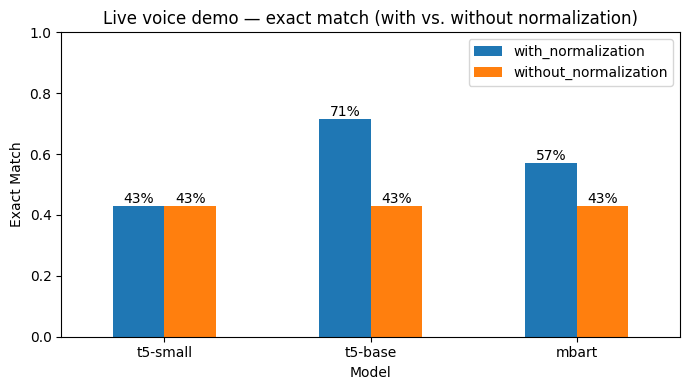

Chart saved to /content/drive/MyDrive/nlp-robot-command-parser/results/comparison_voice_demo.png


In [13]:
# with vs. without normalization per model
if voice_rows:
    ax = df_voice_summary[['with_normalization', 'without_normalization']].plot(
        kind='bar', figsize=(7, 4), rot=0
    )
    ax.set_title('Live voice demo — exact match (with vs. without normalization)')
    ax.set_ylabel('Exact Match')
    ax.set_xlabel('Model')
    ax.set_ylim(0, 1)
    ax.legend(title='')

    for container in ax.containers:
        labels = []
        for v in container.datavalues:
            label = f'{v:.0%}'
            labels.append(label)
        ax.bar_label(container, labels)

    plt.tight_layout()

    out_path = os.path.join(RESULTS_ROOT, 'comparison_voice_demo.png')
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Chart saved to {out_path}')


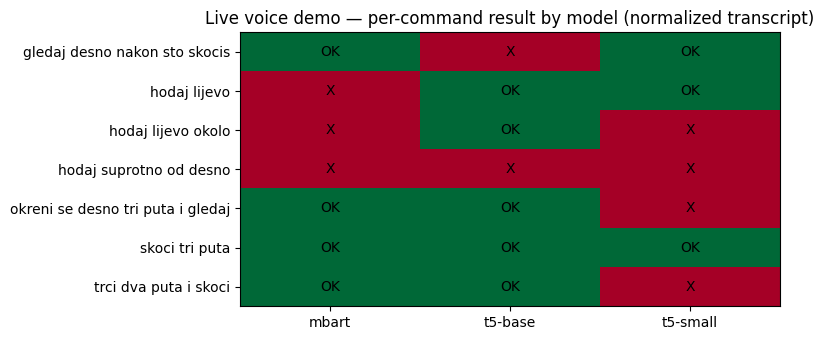

Chart saved to /content/drive/MyDrive/nlp-robot-command-parser/results/comparison_voice_demo_heatmap.png


In [14]:
# per-command heatmap (normalized transcript result, per model)
if per_cmd_records:
    df_cmd = pd.DataFrame(per_cmd_records)
    pivot_cmd = df_cmd.pivot(index='said', columns='model', values='correct_norm')

    fig, ax = plt.subplots(figsize=(8, max(3, 0.5 * len(pivot_cmd))))
    im = ax.imshow(pivot_cmd.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

    ax.set_xticks(range(len(pivot_cmd.columns)))
    ax.set_xticklabels(pivot_cmd.columns)
    ax.set_yticks(range(len(pivot_cmd.index)))
    ax.set_yticklabels(pivot_cmd.index)

    for i in range(len(pivot_cmd.index)):
        for j in range(len(pivot_cmd.columns)):
            val = pivot_cmd.values[i, j]

            if val == 1:
                label = 'OK'
            elif val == 0:
                label = 'X'
            else:
                label = '—'

            ax.text(j, i, label, ha='center', va='center', color='black')

    ax.set_title('Live voice demo — per-command result by model (normalized transcript)')
    plt.tight_layout()

    out_path = os.path.join(RESULTS_ROOT, 'comparison_voice_demo_heatmap.png')
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f'Chart saved to {out_path}')
